In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Resume.csv')

In [ ]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


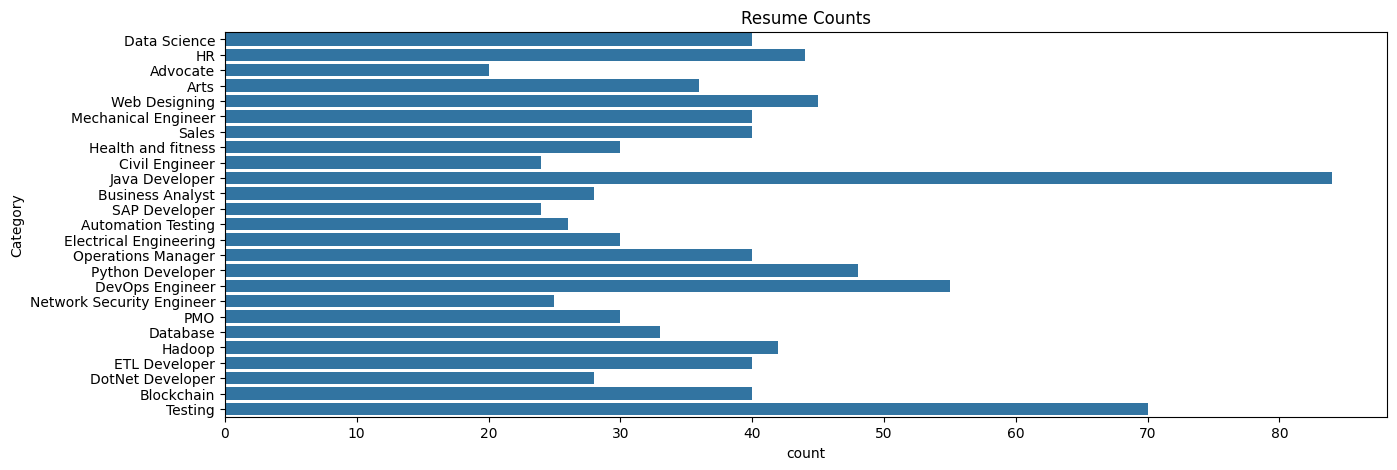

In [ ]:
plt.figure(figsize = (15,5))
sns.countplot(df['Category'])
plt.title('Resume Counts')
plt.show()

In [ ]:
# Oversampling to handle class imbalanace

max_size = df['Category'].value_counts().max()
balanced_df = df.groupby("Category").apply(lambda x: x.sample(max_size,replace = True)).reset_index(drop=True)
df = balanced_df.sample(frac = 1).reset_index(drop = True)

/tmp/ipykernel_5233/2335715144.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("Category").apply(lambda x: x.sample(max_size,replace = True)).reset_index(drop=True)


In [ ]:
balanced_df['Category'].value_counts()

,count
Category,
Advocate,84
Arts,84
Automation Testing,84
Blockchain,84
Business Analyst,84
Civil Engineer,84
Data Science,84
Database,84
DevOps Engineer,84


In [ ]:
df.iloc[81:90]

,Category,Resume
81,Civil Engineer,Computer Skills â¢ Holder of valid KSA licens...
82,HR,Education Details \r\n BA mumbai University\...
83,Civil Engineer,Computer Skills â¢ Holder of valid KSA licens...
84,Python Developer,TECHNICAL PROFICIENCIES Platform: Ubuntu/Fedor...
85,Testing,Computer Skills: â¢ Proficient in MS office (...
86,Health and fitness,Education Details \r\nJanuary 1992 to January ...
87,SAP Developer,Skills: â¢ ETL â¢ Data Warehousing â¢ SQL/P...
88,PMO,AREA OF EXPERTISE (PROFILE) Around 10 plus yea...
89,HR,KEY SKILLS: â¢ Computerized accounting with t...


## Cleaning Data



1.   URLs
1.   Hashtags
2.   Special Characters
2.   Punctuation



In [ ]:
import re
def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5233/3739445999.py:3: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('http\S+\s', ' ', txt)
/tmp/ipykernel_5233/3739445999.py:5: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('#\S+\s', ' ', cleanText)
/tmp/ipykernel_5233/3739445999.py:6: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('@\S+', '  ', cleanText)
/tmp/ipykernel_5233/3739445999.py:7: SyntaxWarning: invalid escape sequence '\]'
  cleanText = re.sub('[%s]' % re.escape

In [ ]:
cleanResume("hii :), I am MIA !!")

'hii I am MIA '

In [ ]:
df["Resume"][0]

"Education Details \r\nJuly 2008 to February 2012 BE COMPUTER SCIENCE Nagpur, Maharashtra NAGPUR UNIVERSITY\r\nSAP HANA Developer \r\n\r\nSAP HANA Developer - Schlumberger\r\nSkill Details \r\nSAP HANA- Exprience - 60 months\r\nSAP BO- Exprience - 36 monthsCompany Details \r\ncompany - Schlumberger\r\ndescription - Schlumberger is the world's leading provider of technology for reservoir characterization, drilling, production, and processing to the oil and gas industry. Working in more than 85 countries.\r\nRole-SAP HANA Developer\r\nTeam Size: 12\r\nDuration: Feb 2017 to Till Date\r\nResponsibilities:\r\nWorking on Suit on HANA and Native HANA Systems.\r\nWorking on end to end implementation for Release 2.3 and 2.4.\r\nDeveloping HANA Information Models Calculation Views, Table Functions, Procedures.\r\nActively involved in cutover activities, Dry Runs Production Go live and Post Production Go Live and resolving issues.\r\nWorked on HANA functionalities like Currency Conversions and an

In [ ]:
df["Resume"] = df["Resume"].apply(lambda x : cleanResume(x))
df["Resume"][0]

'Education Details July 2008 to February 2012 BE COMPUTER SCIENCE Nagpur Maharashtra NAGPUR UNIVERSITY SAP HANA Developer SAP HANA Developer Schlumberger Skill Details SAP HANA Exprience 60 months SAP BO Exprience 36 monthsCompany Details company Schlumberger description Schlumberger is the world s leading provider of technology for reservoir characterization drilling production and processing to the oil and gas industry Working in more than 85 countries Role SAP HANA Developer Team Size 12 Duration Feb 2017 to Till Date Responsibilities Working on Suit on HANA and Native HANA Systems Working on end to end implementation for Release 2 3 and 2 4 Developing HANA Information Models Calculation Views Table Functions Procedures Actively involved in cutover activities Dry Runs Production Go live and Post Production Go Live and resolving issues Worked on HANA functionalities like Currency Conversions and analyzing the Planviz for performance related issues etc Worked on to bring the Tables in

In [ ]:
df.head()

,Category,Resume
0,SAP Developer,Education Details July 2008 to February 2012 B...
1,Data Science,Expertise Data and Quantitative Analysis Decis...
2,Advocate,SKILLS Knows English as native speaker IELTS O...
3,Web Designing,Education Details B C A Bachelor Computer Appl...
4,Data Science,Expertise Data and Quantitative Analysis Decis...


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
le.fit(df["Category"])
df['Category'] = le.transform(df['Category'])
df['Category'].unique()

array([21,  6,  0, 24, 20, 23, 17, 16, 18,  1,  5, 19, 12, 11, 13,  4, 10,
       15,  8,  7, 14,  2,  3, 22,  9])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfid = TfidfVectorizer(stop_words = 'english')
tfid.fit(df["Resume"])
required_text = tfid.transform(df["Resume"])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(required_text, df["Category"], test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(X_train,y_train)
y_pred = svc_model.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [ ]:
def pred(Resume_input):
  # Preprocessing
  cleaned_text = cleanResume(Resume_input)

  # Convert text into numeric values
  numeric_text = tfid.transform([cleaned_text]) # stores in a matrix

  # Convert matrix to array
  numeric_text = numeric_text.toarray()

  # Prediction
  predicted_category = svc_model.predict(numeric_text)

  # Inverse Transform: num is converted back to textual value
  predicted_category_name = le.inverse_transform(predicted_category)

  return predicted_category_name[0]


In [ ]:
myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

In [ ]:
pred(myresume)

'Data Science'

In [ ]:
myresume = """
Jane Smith is a certified personal trainer with over 5 years of experience in helping individuals achieve their fitness goals. Specializing in weight loss, strength training, and sports conditioning, Jane has developed personalized workout routines for clients of all ages and fitness levels. She has extensive knowledge in nutrition and exercise science, and uses this to create holistic health and fitness programs that are tailored to individual needs.

Jane holds a degree in Exercise Science and is a certified trainer through the National Academy of Sports Medicine (NASM). She has worked with athletes, seniors, and individuals with chronic health conditions, helping them improve their physical well-being and overall quality of life.

Her expertise includes:
- Weight Loss and Body Composition
- Strength Training and Resistance Exercises
- Cardio Conditioning
- Nutrition Coaching and Meal Planning
- Injury Prevention and Rehabilitation
- Functional Movement and Flexibility Training
- Group Fitness Classes

Certifications:
- Certified Personal Trainer, NASM
- CPR and First Aid Certified
- Yoga Instructor (200-Hour Certification)

Education:
BSc in Exercise Science, ABC University, 2014-2018

Work Experience:
- Personal Trainer at XYZ Fitness Gym (2018-Present)
- Fitness Coach at Wellness Center (2016-2018)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

In [ ]:
pred(myresume)

'Health and fitness'